# 🔬 Test Model - Sonar Returns Classification
**Bài toán:** Binary Classification – Mine (M) vs Rock (R)  
**Mục đích:** Load model tốt nhất đã train và cho phép thêm dữ liệu test theo ý người dùng


## Bước 10: Khởi tạo thí nghiệm Test

In [1]:
# ── Khai báo thư viện ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle, warnings
from datetime import datetime
from openpyxl import load_workbook
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay)

TRAIN_DATA_NAME = 'sonar'
TEST_DATA_NAME  = 'sonar'

BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'prj' else os.getcwd()
EXP_DIR   = os.path.join(BASE_DIR, 'exps_', TEST_DATA_NAME)
MODEL_DIR = os.path.join(BASE_DIR, 'model', TRAIN_DATA_NAME)
BEST_MODEL_PATH = os.path.join(MODEL_DIR, f'{TRAIN_DATA_NAME}__best_model.pkl')
TEST_LOG  = os.path.join(EXP_DIR, f'{TRAIN_DATA_NAME}__test_{TEST_DATA_NAME}_log.xlsx')
PREDICTION_CSV = os.path.join(EXP_DIR, f'{TRAIN_DATA_NAME}__test_{TEST_DATA_NAME}_predictions.csv')

FEATURES = [f'F{i+1:02d}' for i in range(60)]
TEST_FILES = {
    'raw':      os.path.join(EXP_DIR, 'test_raw.csv'),
    'minmax':   os.path.join(EXP_DIR, 'test_minmax.csv'),
    'standard': os.path.join(EXP_DIR, 'test_standard.csv'),
}

W_ACC = 0.4
W_F1  = 0.3
W_AUC = 0.3
COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52',
          '#8172B2','#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print('✅ Khai báo thư viện và tham số xong!')
print(f'   TRAIN_DATA_NAME : {TRAIN_DATA_NAME}')
print(f'   TEST_DATA_NAME  : {TEST_DATA_NAME}')
print(f'   EXP_DIR         : {EXP_DIR}')
print(f'   BEST_MODEL_PATH : {BEST_MODEL_PATH}')
print(f'   TEST_LOG        : {TEST_LOG}')


✅ Khai báo thư viện và tham số xong!
   TRAIN_DATA_NAME : sonar
   TEST_DATA_NAME  : sonar
   EXP_DIR         : D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar
   BEST_MODEL_PATH : D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\model\sonar\sonar__best_model.pkl
   TEST_LOG        : D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\sonar__test_sonar_log.xlsx


## Bước 11: Kiểm tra điều kiện trước khi test

In [2]:
errors = []
pkl_count = 0

if not os.path.isdir(MODEL_DIR):
    errors.append(f'[THIẾU MODEL FOLDER] {MODEL_DIR}')
else:
    pkl_files = [f for f in os.listdir(MODEL_DIR) if f.endswith('.pkl')]
    pkl_count = len(pkl_files)
    if not os.path.exists(BEST_MODEL_PATH):
        errors.append(f'[THIẾU BEST MODEL] {BEST_MODEL_PATH}')

for sn, fp in TEST_FILES.items():
    if not os.path.exists(fp):
        errors.append(f'[THIẾU CSV] {fp}')

if errors:
    print('=' * 70)
    print('❌ TỪ CHỐI TEST – Các điều kiện chưa đủ!')
    for e in errors:
        print(' -', e)
    print('   → Hãy chạy lại 02_train.ipynb để export đúng best model bundle.')
    print('=' * 70)
    raise SystemExit('Điều kiện chưa đủ – dừng lại!')
else:
    print('=' * 70)
    print('✅ TẤT CẢ ĐIỀU KIỆN THỎA MÃN – Sẵn sàng test!')
    print(f'   Model files : {pkl_count}')
    print(f'   Best model  : {os.path.basename(BEST_MODEL_PATH)}')
    for fp in TEST_FILES.values():
        print(f'   [OK] {fp}')
    print('=' * 70)


✅ TẤT CẢ ĐIỀU KIỆN THỎA MÃN – Sẵn sàng test!
   Model files : 1
   Best model  : sonar__best_model.pkl
   [OK] D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\test_raw.csv
   [OK] D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\test_minmax.csv
   [OK] D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\test_standard.csv


## Bước 12: Load model đã train

Bước test chỉ load **duy nhất** `best_model.pkl` đã được chốt ở `02_train.ipynb`.
Notebook **không** quét toàn bộ `.pkl` trong thư mục model và cũng **không** chọn lại best model trên tập test.


In [3]:
with open(BEST_MODEL_PATH, 'rb') as f:
    best_bundle = pickle.load(f)

required_keys = {'model', 'model_name', 'scaler_name'}
if not isinstance(best_bundle, dict) or not required_keys.issubset(best_bundle):
    raise ValueError(
        'best_model.pkl chưa đúng định dạng bundle mới. '
        'Hãy chạy lại 02_train.ipynb trước khi test.'
    )

best_model = best_bundle['model']
best_name = best_bundle['model_name']
best_scaler = best_bundle['scaler_name']
cv_metrics = best_bundle.get('cv_metrics') or best_bundle.get('metrics', {})

all_models = {best_scaler: {best_name: best_model}}

print(f'=== MODEL ĐÃ LOAD TỪ {MODEL_DIR} ===')
print(f'   File   : {os.path.basename(BEST_MODEL_PATH)}')
print(f'   Model  : {best_name}')
print(f'   Scaler : {best_scaler}')
if cv_metrics:
    print(f'   CV Acc : {cv_metrics.get("Accuracy", np.nan):.4f}')
    print(f'   CV F1  : {cv_metrics.get("F1", np.nan):.4f}')
    print(f'   CV AUC : {cv_metrics.get("ROC_AUC", np.nan):.4f}')


=== MODEL ĐÃ LOAD TỪ D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\model\sonar ===
   File   : sonar__best_model.pkl
   Model  : SVM (tuned)
   Scaler : minmax
   CV Acc : 0.8966
   CV F1  : 0.9059
   CV AUC : 0.9473


## Bước 13: Dữ liệu kiểm nghiệm

Tập test ở bước này chỉ lấy từ các file `test_raw.csv`, `test_minmax.csv`, `test_standard.csv`
đã được xuất ra ở `01_eda.ipynb`.


In [4]:
def load_test(path):
    df = pd.read_csv(path)
    return df.iloc[:, :-1].values, df.iloc[:, -1].values, df.copy()

official_test = {}
print('=== KIỂM TRA FILE TEST CHÍNH THỨC ===')
for sn, path in TEST_FILES.items():
    X, y, df = load_test(path)
    official_test[sn] = df.copy()
    print(f'[{sn:8s}] {os.path.basename(path)} | Shape: {X.shape} | Classes: {np.unique(y)}')


=== KIỂM TRA FILE TEST CHÍNH THỨC ===
[raw     ] test_raw.csv | Shape: (63, 60) | Classes: ['M' 'R']
[minmax  ] test_minmax.csv | Shape: (63, 60) | Classes: ['M' 'R']
[standard] test_standard.csv | Shape: (63, 60) | Classes: ['M' 'R']


## Bước 14: Đánh giá model trên tập Test

Chỉ đánh giá **best model** đã được chốt ở bước train trên đúng phiên bản dữ liệu test
tương ứng với scaler của model đó.


In [5]:
pos_label = 'M'
eval_df = official_test[best_scaler].copy()
eval_df['source'] = 'official'

X_eval = eval_df[FEATURES].values
y_eval = eval_df['class'].values
y_pred = best_model.predict(X_eval)

score = None
auc = np.nan
if hasattr(best_model, 'predict_proba'):
    pos_idx = list(best_model.classes_).index(pos_label)
    score = best_model.predict_proba(X_eval)[:, pos_idx]
    auc = roc_auc_score((y_eval == pos_label).astype(int), score)
elif hasattr(best_model, 'decision_function'):
    score = best_model.decision_function(X_eval)
    auc = roc_auc_score((y_eval == pos_label).astype(int), score)

acc = accuracy_score(y_eval, y_pred)
f1 = f1_score(y_eval, y_pred, pos_label=pos_label, zero_division=0)
composite = round(W_ACC * acc + W_F1 * f1 + W_AUC * (auc if not np.isnan(auc) else 0), 4)

test_results = [{
    'Scaler': best_scaler,
    'Model': best_name,
    'Accuracy': round(acc, 4),
    'F1': round(f1, 4),
    'ROC_AUC': round(auc, 4) if not np.isnan(auc) else None,
    'Composite': composite,
    'Labeled samples': int(len(y_eval)),
}]
df_test = pd.DataFrame(test_results)

df_predictions = eval_df.copy()
df_predictions['scaler'] = best_scaler
df_predictions['model'] = best_name
df_predictions['prediction'] = y_pred
if score is not None:
    if hasattr(best_model, 'predict_proba'):
        df_predictions[f'prob_{pos_label}'] = score
    else:
        df_predictions['decision_score'] = score

best_overall = {
    'composite': composite,
    'model': best_model,
    'name': best_name,
    'scaler': best_scaler,
    'accuracy': acc,
    'f1': f1,
    'roc_auc': auc,
}

print()
print(f'📊 [{best_scaler.upper()}] Test trên {TEST_DATA_NAME}:')
print(f'  {"Model":<26} {"Acc":>7} {"F1":>7} {"AUC":>7} {"Composite":>10}')
print('  ' + '-' * 64)
auc_str = f'{auc:.4f}' if not np.isnan(auc) else 'N/A'
print(f'  {best_name:<26} {acc:>7.4f} {f1:>7.4f} {auc_str:>7} {composite:>10.4f}')



📊 [MINMAX] Test trên sonar:
  Model                          Acc      F1     AUC  Composite
  ----------------------------------------------------------------
  SVM (tuned)                 0.8889  0.8986  0.9249     0.9026


## Bước 15: Bảng điểm Test


In [6]:
display(df_test)
if cv_metrics:
    print('\nCV metrics từ bước train:')
    print(f'   Accuracy  : {cv_metrics.get("Accuracy", np.nan):.4f}')
    print(f'   F1        : {cv_metrics.get("F1", np.nan):.4f}')
    print(f'   ROC_AUC   : {cv_metrics.get("ROC_AUC", np.nan):.4f}')
    print(f'   Composite : {cv_metrics.get("Composite", np.nan):.4f}')


,Scaler,Model,Accuracy,F1,ROC_AUC,Composite,Labeled samples
0,minmax,SVM (tuned),0.8889,0.8986,0.9249,0.9026,63



CV metrics từ bước train:
   Accuracy  : 0.8966
   F1        : 0.9059
   ROC_AUC   : 0.9473
   Composite : 0.9146


## Bước 16: Biểu đồ Test Metrics


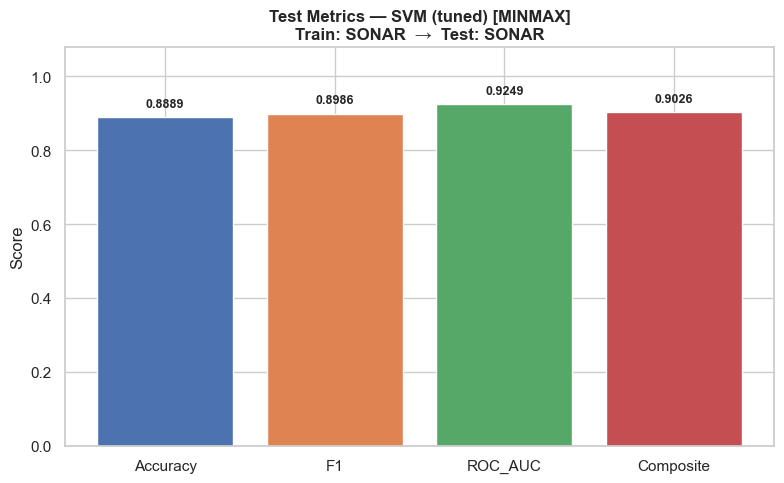

In [7]:
metric_labels = ['Accuracy', 'F1', 'ROC_AUC', 'Composite']
metric_values = [best_overall['accuracy'], best_overall['f1'], best_overall['roc_auc'], best_overall['composite']]
plot_values = [0 if pd.isna(v) else v for v in metric_values]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metric_labels, plot_values, color=COLORS[:len(metric_labels)], edgecolor='white')
ax.set_ylim(0.0, 1.08)
ax.set_ylabel('Score')
ax.set_title(
    f'Test Metrics — {best_name} [{best_scaler.upper()}]\n'
    f'Train: {TRAIN_DATA_NAME.upper()}  →  Test: {TEST_DATA_NAME.upper()}',
    fontweight='bold'
)
for bar, raw_value in zip(bars, metric_values):
    label = 'N/A' if pd.isna(raw_value) else f'{raw_value:.4f}'
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, label,
            ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, f'{TRAIN_DATA_NAME}__test_{TEST_DATA_NAME}_plot_metrics.png'), bbox_inches='tight')
plt.show()


## Bước 17: Confusion Matrix – Best Model

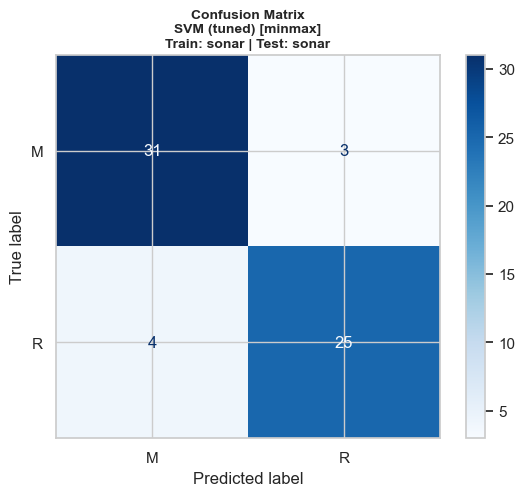


=== Classification Report ===
              precision    recall  f1-score   support

           M       0.89      0.91      0.90        34
           R       0.89      0.86      0.88        29

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63



In [8]:
classes = list(best_model.classes_) if hasattr(best_model, 'classes_') else sorted(np.unique(y_eval))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_eval, y_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(
    f'Confusion Matrix\n{best_name} [{best_scaler}]\nTrain: {TRAIN_DATA_NAME} | Test: {TEST_DATA_NAME}',
    fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, f'{TRAIN_DATA_NAME}__test_{TEST_DATA_NAME}_plot_cm.png'), bbox_inches='tight')
plt.show()

print()
print('=== Classification Report ===')
print(classification_report(y_eval, y_pred, target_names=classes))


## Bước 18: ROC Curves

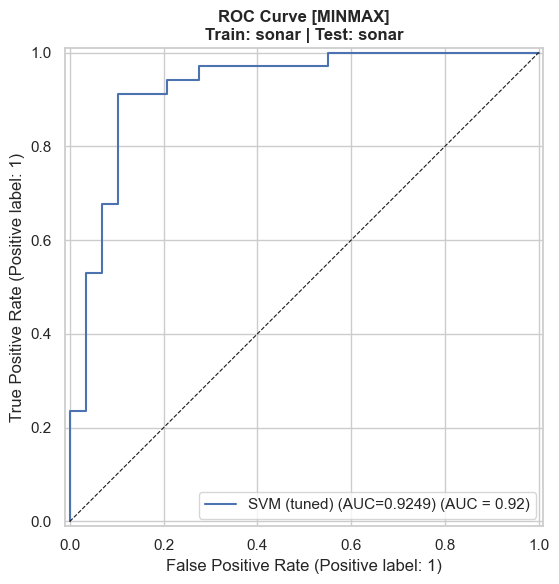

In [9]:
if score is None:
    print('⚠️ Model không hỗ trợ xác suất/decision score nên bỏ qua ROC Curve.')
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    RocCurveDisplay.from_predictions(
        (y_eval == pos_label).astype(int),
        score,
        ax=ax,
        name=f'{best_name} (AUC={best_overall["roc_auc"]:.4f})'
    )
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_title(
        f'ROC Curve [{best_scaler.upper()}]\nTrain: {TRAIN_DATA_NAME} | Test: {TEST_DATA_NAME}',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(os.path.join(EXP_DIR, f'{TRAIN_DATA_NAME}__test_{TEST_DATA_NAME}_plot_roc.png'), bbox_inches='tight')
    plt.show()


## Bước 19: Ghi test_log.xlsx

In [10]:
summary_row = pd.DataFrame([{
    'Thời gian': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Train data': TRAIN_DATA_NAME,
    'Test data': TEST_DATA_NAME,
    'Best model': best_overall['name'],
    'Best scaler': best_overall['scaler'],
    'Accuracy': round(best_overall['accuracy'], 4),
    'F1': round(best_overall['f1'], 4),
    'ROC_AUC': None if np.isnan(best_overall['roc_auc']) else round(best_overall['roc_auc'], 4),
    'Composite': best_overall['composite'],
    'CV Composite': cv_metrics.get('Composite', cv_metrics.get('composite', np.nan)),
    'Custom samples': 0,
    'Append custom': False,
}])

if os.path.exists(TEST_LOG):
    try:
        old = pd.read_excel(TEST_LOG, sheet_name='Lich_su_chay')
        history = pd.concat([old, summary_row], ignore_index=True)
    except Exception:
        history = summary_row
else:
    history = summary_row

if not df_predictions.empty:
    df_predictions.to_csv(PREDICTION_CSV, index=False)

with pd.ExcelWriter(TEST_LOG, engine='openpyxl', mode='w') as writer:
    history.to_excel(writer, sheet_name='Lich_su_chay', index=False)
    df_test.to_excel(writer, sheet_name='Bang_diem_test', index=False)
    if not df_predictions.empty:
        df_predictions.to_excel(writer, sheet_name='Predictions', index=False)

print(f'📝 Đã lưu log: {TEST_LOG}')
if not df_predictions.empty:
    print(f'🧪 Đã lưu dự đoán chi tiết: {PREDICTION_CSV}')
wb = load_workbook(TEST_LOG)
print('Các sheet:', ', '.join(wb.sheetnames))
wb.close()


📝 Đã lưu log: D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\sonar__test_sonar_log.xlsx
🧪 Đã lưu dự đoán chi tiết: D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\sonar__test_sonar_predictions.csv
Các sheet: Lich_su_chay, Bang_diem_test, Predictions


## Tổng kết thực nghiệm Test

In [11]:
print('=' * 70)
print('TỔNG KẾT TEST - SONAR')
print('=' * 70)
print(f'Train data     : {TRAIN_DATA_NAME}')
print(f'Test data      : {TEST_DATA_NAME}')
print(f'Best model     : {best_overall["name"]}')
print(f'Best scaler    : {best_overall["scaler"]}')
print(f'Accuracy       : {best_overall["accuracy"]:.4f}')
print(f'F1             : {best_overall["f1"]:.4f}')
if np.isnan(best_overall["roc_auc"]):
    print('ROC_AUC        : N/A')
else:
    print(f'ROC_AUC        : {best_overall["roc_auc"]:.4f}')
print(f'Composite      : {best_overall["composite"]:.4f}')
print(f'Log file       : {TEST_LOG}')
if not df_predictions.empty:
    print(f'Predictions    : {PREDICTION_CSV}')
print('=' * 70)
print('Flow hiện tại: test chỉ dùng best model từ train và file test đã xử lý ở EDA.')


TỔNG KẾT TEST - SONAR
Train data     : sonar
Test data      : sonar
Best model     : SVM (tuned)
Best scaler    : minmax
Accuracy       : 0.8889
F1             : 0.8986
ROC_AUC        : 0.9249
Composite      : 0.9026
Log file       : D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\sonar__test_sonar_log.xlsx
Predictions    : D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\sonar__test_sonar_predictions.csv
Flow hiện tại: test chỉ dùng best model từ train và file test đã xử lý ở EDA.
